# 04 — Topic modeling par embeddings (BERTopic)

**Objectif (data science).** Découvrir, sans supervision, la **structure
thématique** émergente du corpus UGA directement à partir du texte des résumés,
avec une chaîne état de l'art :

- **embeddings de phrases** (sentence-transformers) ;
- réduction de dimension **UMAP** ;
- **clustering** des documents (KMeans pour un nombre de thèmes maîtrisé ;
  HDBSCAN par densité en variante) ;
- pondération **c-TF-IDF** des termes par thème (**BERTopic**).

Cette approche complète la taxonomie native d'OpenAlex par des thèmes dérivés du
texte réel. Reproductible (graines fixées, `random_state` UMAP). Données réelles.

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic

from lib import set_seeds, OpenAlexClient, load_mart, CONFIG
from lib.viz import community_palette

set_seeds()
pd.set_option("display.max_colwidth", None)  # afficher les termes de thème en entier

/mnt/c/Tonton/Projects/post-OC/offres-emploi/UGA/uga-research-dashboard/notebooks/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Constitution du corpus textuel (titres + résumés)

On tire un échantillon aléatoire de notices et on reconstruit les résumés à
partir de l'index inversé d'OpenAlex (cf. notebook 02).

In [2]:
oa = OpenAlexClient()
sample = oa.sample_works(
    oa.institution_filter(
        **{"from_publication_date": f"{CONFIG.from_year}-01-01", "to_publication_date": f"{CONFIG.to_year}-12-31"}
    ),
    "title,abstract_inverted_index",
    n=1500,
    seed=42,
)

# Les résumés OpenAlex contiennent parfois du balisage MathML/HTML : on le retire.
_JUNK = re.compile(r"<[^>]+>|mml:\S+|&\w+;|https?://\S+")


def clean(text: str) -> str:
    return _JUNK.sub(" ", text)


docs = []
for w in sample:
    title = w.get("title") or ""
    abstract = OpenAlexClient.reconstruct_abstract(w.get("abstract_inverted_index"))
    text = clean(f"{title}. {abstract}").strip()
    if len(text) > 60:  # on écarte les notices sans texte exploitable
        docs.append(text)
print(f"Documents exploitables : {len(docs):,}")

Documents exploitables : 1,413


## 2. Chaîne de topic modeling (déterministe)

`random_state=42` sur UMAP et KMeans fige entièrement le résultat. On fixe le
nombre de thèmes (12) pour une lecture claire ; les mots vides français et
anglais sont retirés du calcul c-TF-IDF.

In [3]:
FRENCH_STOP = (
    "le la les un une des du de au aux et ou mais donc or ni car en dans sur sous par pour avec sans "
    "ce cet cette ces se sa son ses leur leurs nous vous ils elles on est sont etre ete avait ont plus "
    "moins tres entre vers chez comme ainsi dont qui que quoi cela ses notre nos votre vos lors afin "
    "selon deux apres avant aussi non oui ne pas elle"
).split()
JUNK = ["mml", "math", "mathrm", "mathbf", "textit", "amp", "org", "http", "https", "www", "doi", "xmlns",
        "xml", "sub", "sup", "span", "study", "results", "using", "based", "show", "data", "however", "also",
        "audience", "international audience", "honoraria", "consultancy", "elsevier", "springer", "wiley",
        "ifi", "haplo"]  # fragments peu lisibles écartés du c-TF-IDF
STOPWORDS = list(CountVectorizer(stop_words="english").get_stop_words()) + FRENCH_STOP + JUNK

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embed_model.encode(docs, show_progress_bar=False, batch_size=64)

topic_model = BERTopic(
    embedding_model=embed_model,
    umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42),
    hdbscan_model=KMeans(n_clusters=12, random_state=42, n_init=10),
    vectorizer_model=CountVectorizer(
        stop_words=STOPWORDS, ngram_range=(1, 2), token_pattern=r"(?u)\b[a-zA-Zàâçéèêëîïôûù]{3,}\b"
    ),
    calculate_probabilities=False,
    verbose=False,
)
topics = topic_model.fit_transform(docs, embeddings)[0]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2992.71it/s]

## 3. Thèmes découverts

Chaque thème est résumé par ses termes c-TF-IDF les plus discriminants, qui
révèlent le vocabulaire spécifique de chaque front de recherche.

In [4]:
info = topic_model.get_topic_info()
n_topics = len(info[info.Topic != -1])
print(f"Thèmes découverts : {n_topics} sur {len(docs):,} documents")

themes = []
for _, row in info[info.Topic != -1].head(10).iterrows():
    words = ", ".join(w for w, _ in topic_model.get_topic(row.Topic)[:6])
    themes.append({"thème": int(row.Topic), "documents": int(row.Count), "termes": words})
pd.DataFrame(themes)

Thèmes découverts : 12 sur 1,413 documents


,thème,documents,termes
0,0,244,"international, analyse, households, étude, article, projet"
1,1,173,"patients, associated, brain, disease, treatment, sleep"
2,2,168,"ice, surface, climate, snow, model, models"
3,3,158,"high, electrode, silicon, temperature, low, layer"
4,4,143,"model, time, estimation, algorithm, proposed, problem"
5,5,117,"mass, disk, observations, dust, high, band"
6,6,102,"protein, proteins, binding, complex, structure, membrane"
7,7,89,"particles, soil, flow, liquid, experimental, model"
8,8,73,"magnetic, quantum, field, spin, transition, superconducting"
9,9,63,"patients, cell, cells, mice, aml, cell lines"


## 4. Taille des principaux thèmes

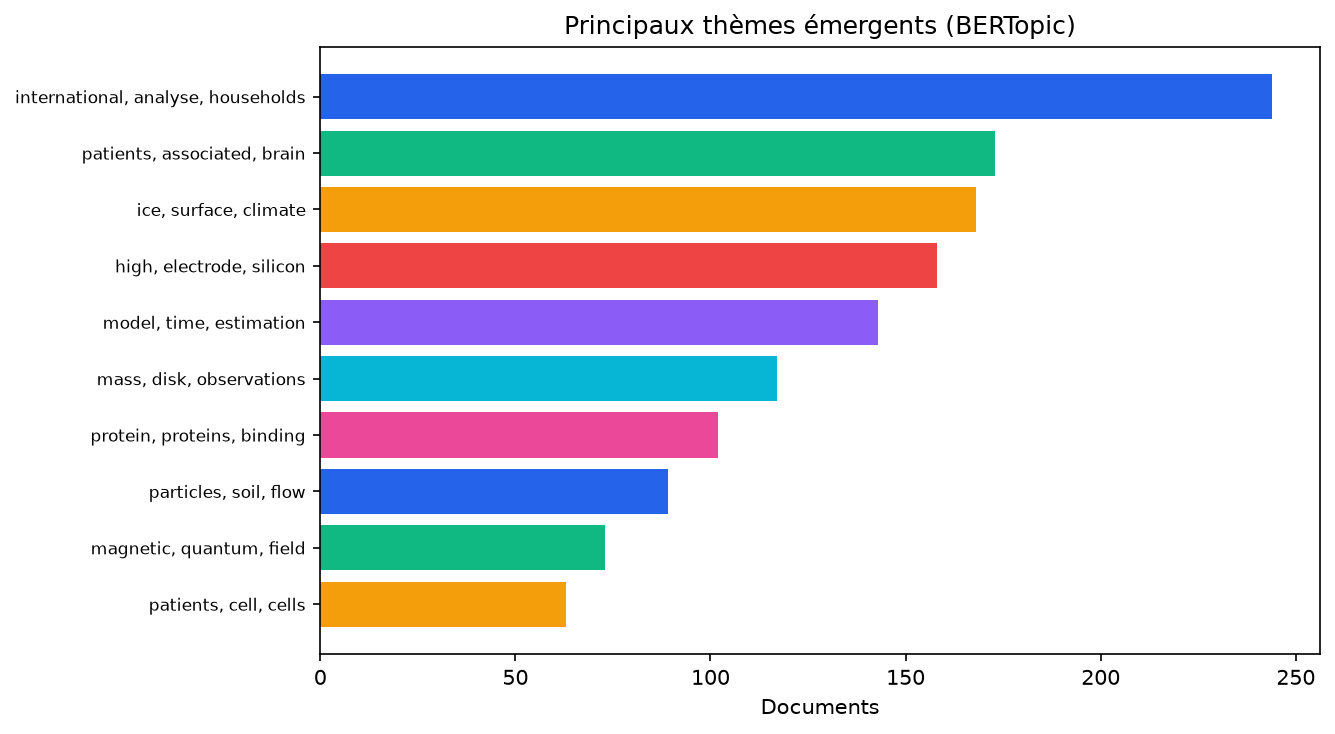

In [5]:
top = info[info.Topic != -1].head(10)
labels = [", ".join(w for w, _ in topic_model.get_topic(t)[:3]) for t in top.Topic]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(top)), top.Count, color=[community_palette(i) for i in range(len(top))])
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Documents")
ax.set_title("Principaux thèmes émergents (BERTopic)")
plt.tight_layout()
plt.show()

## 5. Projection 2D du corpus (UMAP)

Visualisation des documents projetés en 2D, colorés par thème : les regroupements
denses correspondent aux fronts de recherche identifiés.

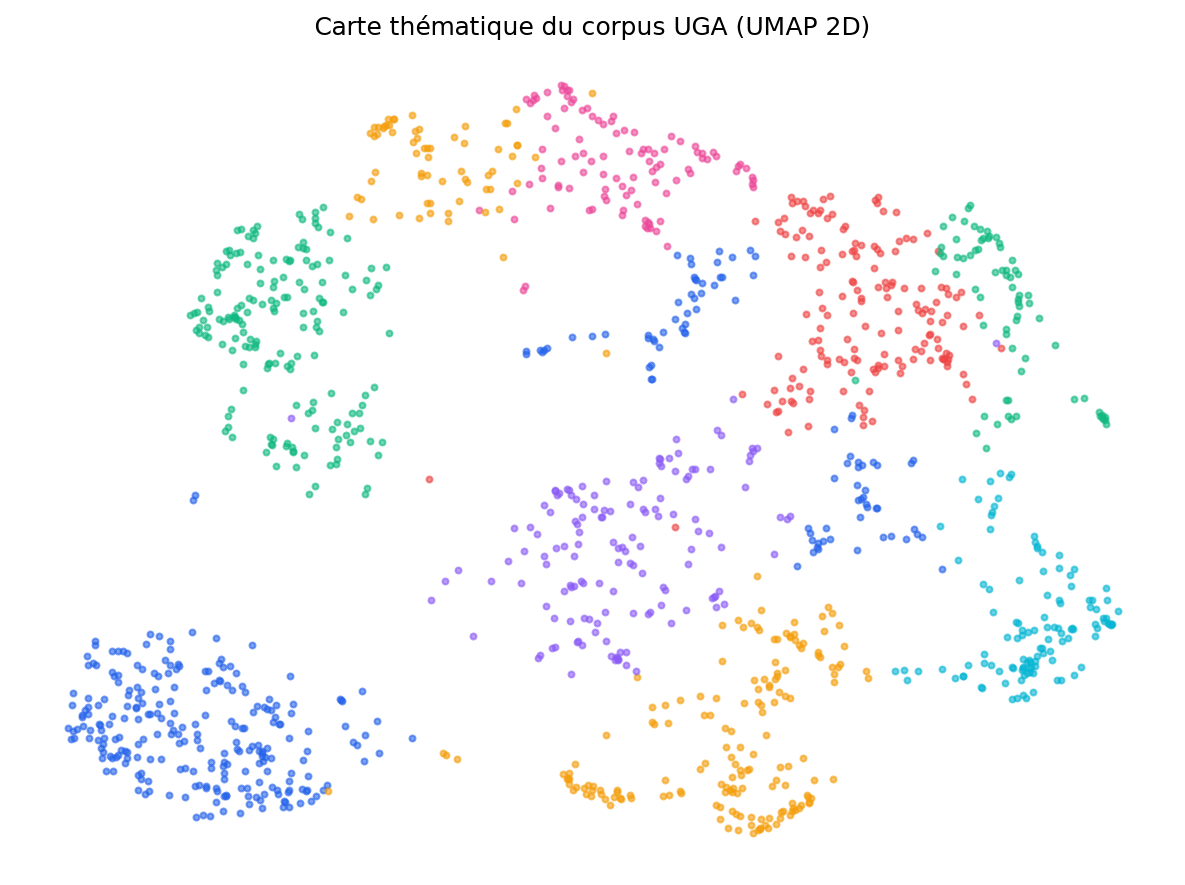

In [6]:
coords = UMAP(n_components=2, metric="cosine", random_state=42).fit_transform(embeddings)
fig, ax = plt.subplots(figsize=(8, 6))
for t in top.Topic:
    mask = [tp == t for tp in topics]
    pts = coords[mask]
    ax.scatter(pts[:, 0], pts[:, 1], s=8, color=community_palette(int(t)), alpha=0.6)
ax.set_title("Carte thématique du corpus UGA (UMAP 2D)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Mise en regard avec la taxonomie OpenAlex

Les thèmes émergents (issus du texte) sont à rapprocher des topics OpenAlex
(supervisés) du mart `topics` : les deux doivent désigner des domaines forts
cohérents (matériaux, santé, physique, environnement…).

In [7]:
topics_mart = load_mart("topics")
top_oa = topics_mart.get("topics", [])[:8]
print("Topics OpenAlex de référence (mart) :")
for t in top_oa:
    print("  -", t.get("name", t.get("label", "?")))

Topics OpenAlex de référence (mart) :
  - Cryospheric studies and observations
  - Particle physics theoretical and experimental studies
  - French Urban and Social Studies
  - Astrophysics and Star Formation Studies
  - Stellar, planetary, and galactic studies
  - Semiconductor materials and devices
  - Obstructive Sleep Apnea Research
  - Education, sociology, and vocational training


**Lecture.** Sans aucune supervision, la chaîne embeddings → UMAP → KMeans
(12 thèmes) retrouve des fronts de recherche cohérents avec les forces connues de l'UGA et
avec la taxonomie OpenAlex. L'intérêt : ces thèmes sont dérivés du **texte
réel**, donc sensibles aux signaux émergents que des catégories figées
manqueraient. Chaîne entièrement reproductible.